In [1]:
from src.generate_surface_code import SurfaceCode
from src.TN_decoder import decoder
from decoder import run_shots
import stim
import pymatching
import time
from matplotlib import pyplot as plt

## Surface Code objects
This project uses instances of a class called ```SurfaceCode``` to generate the required ```Stim``` circuit, its _DetectorErrorModel_(dem) and various other attributes useful for decoding. The object is defined using input parameters

1. code_distance (int) : Code distance
2. noise_model (str) : Noise model to be used. We currently support only ```'depolarize'``` or ```'bit-flip'.```
3. noise (float) : Noise to be used with noise model.


In [2]:
#Setting model parameters
distance = 3
noise_model = "depolarize"
noise = 0.1

In [3]:
code = SurfaceCode(distance, noise_model, noise)

In [4]:
#We can look at the circuit generated from these parameters
code.circuit

stim.Circuit('''
    MPP X1*X0*X3 X2*X1*X4 X6*X5*X8*X3 X7*X6*X9*X4 X11*X10*X8 X12*X11*X9 Z3*Z5*Z0 Z4*Z3*Z6*Z1 Z4*Z7*Z2 Z8*Z10*Z5 Z9*Z8*Z11*Z6 Z9*Z12*Z7 Z0*Z1*Z2
    DEPOLARIZE1(0.1) 0 1 2 3 4 5 6 7 8 9 10 11 12
    MPP X1*X0*X3 X2*X1*X4 X6*X5*X8*X3 X7*X6*X9*X4 X11*X10*X8 X12*X11*X9 Z3*Z5*Z0 Z4*Z3*Z6*Z1 Z4*Z7*Z2 Z8*Z10*Z5 Z9*Z8*Z11*Z6 Z9*Z12*Z7 Z0*Z1*Z2
    DETECTOR(1, 0, 0) rec[-26] rec[-13]
    DETECTOR(3, 0, 0) rec[-25] rec[-12]
    DETECTOR(1, 2, 0) rec[-24] rec[-11]
    DETECTOR(3, 2, 0) rec[-23] rec[-10]
    DETECTOR(1, 4, 0) rec[-22] rec[-9]
    DETECTOR(3, 4, 0) rec[-21] rec[-8]
    DETECTOR(0, 1, 0) rec[-20] rec[-7]
    DETECTOR(2, 1, 0) rec[-19] rec[-6]
    DETECTOR(4, 1, 0) rec[-18] rec[-5]
    DETECTOR(0, 3, 0) rec[-17] rec[-4]
    DETECTOR(2, 3, 0) rec[-16] rec[-3]
    DETECTOR(4, 3, 0) rec[-15] rec[-2]
    OBSERVABLE_INCLUDE(0) rec[-14] rec[-1]
''')

 We now sample this circuit to create detection events that will eventually be passed to our detector.

In [5]:

sampler = code.circuit.compile_detector_sampler()
nshots = 1000 #Number of shots to be sampled

detection_events, observable_flips = sampler.sample(shots = nshots, separate_observables = True)

```detection_events``` can now be passed to our detector for decoding.

In [6]:
chi = 6 #Maximum bond dimension to be kept during tensor network operations.
predictions = []
for event in detection_events:
    predictions.append(decoder(code, event, chi))

In [7]:
fails = sum([1 if not predictions[j] == observable_flips[j] else 0 for j in range(nshots)])
print(f"The observed error rate = {fails/nshots*100:.3f}%")

The observed error rate = 4.900%


This process can be shortened by using the ```run_shots``` methods. We can simply pass it the model parameters, along wioth the number of shots to be taken and the maximum bond dimension to be kept. It returns the number of failed logical predictions.

In [8]:
nfails = run_shots(distance, noise_model, noise, chi, nshots)

In [9]:
print(f"Error rate = {nfails/nshots*100:.3f}%")

Error rate = 5.500%


## Comparison with MWPM
We now do some basic benchmarking against pymatching's MWPM decoder

In [10]:
def MWPM_decoding(code, nshots):

    sampler = code.circuit.compile_detector_sampler()

    detection_events, observable_flips = sampler.sample(shots = nshots, separate_observables = True)

    matcher = pymatching.Matching.from_detector_error_model(code.dem)

    predictions = matcher.decode_batch(detection_events)

    nfails = sum([1 if not predictions[j] == observable_flips[j] else 0 for j in range(nshots)])

    return nfails

### Depolarizing noise

In [44]:
distance = 5
noise_model = 'depolarize'
noises = [0.12, 0.14, 0.16, 0.18, 0.2, 0.22, 0.24]
nshots = 1000

code = SurfaceCode(distance, noise_model, noise)

In [45]:
MWPM_times = []
TN_times = []
MWPM_rates = []
TN_rates = []
for noise in noises:
    start_MWPM_time = time.perf_counter()
    MWPM_fails = MWPM_decoding(code, nshots)
    end_MWPM_time = time.perf_counter()

    start_TN_time = time.perf_counter()
    TN_fails = run_shots(distance,noise_model,noise,chi,nshots)
    end_TN_time = time.perf_counter()

    MWPM_times.append(end_MWPM_time - start_MWPM_time)
    TN_times.append(end_TN_time - start_TN_time)
    MWPM_rates.append(MWPM_fails/nshots)
    TN_rates.append(TN_fails/nshots)

Text(-0.1, 1, 'Depolarizing noise')

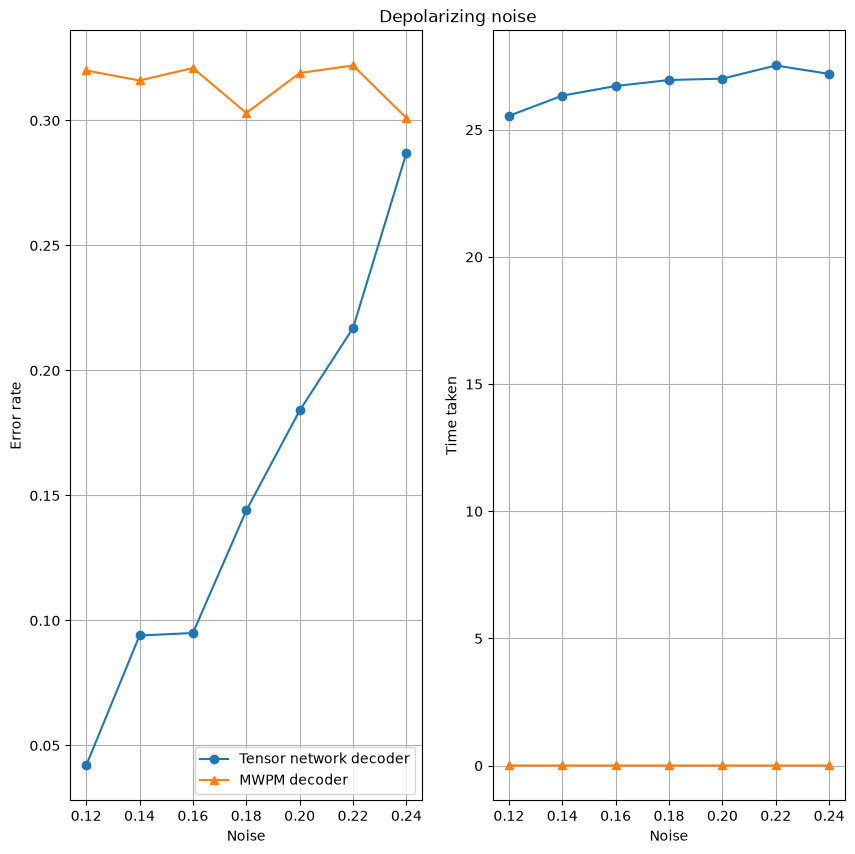

In [46]:
fig, axes = plt.subplots(1,2, figsize = (10,10))

axes[0].plot(noises,TN_rates, marker = 'o', label = 'Tensor network decoder')
axes[0].plot(noises,MWPM_rates, marker = '^', label = 'MWPM decoder')

axes[1].plot(noises, TN_times, marker= 'o')
axes[1].plot(noises, MWPM_times, marker = '^')

axes[0].set_xlabel('Noise')
axes[1].set_xlabel('Noise')
axes[0].set_ylabel('Error rate')
axes[1].set_ylabel('Time taken')

axes[0].legend()

axes[0].grid(True)
axes[1].grid(True)

plt.title("Depolarizing noise", x=-.1,y=1)

### Bit-flip noise

In [48]:
distance = 5
noise_model = 'bit-flip'
noises = [0.05, 0.07, 0.09, 0.11, 0.13, 0.15]
nshots = 1000

code = SurfaceCode(distance, noise_model, noise)

In [49]:
MWPM_times = []
TN_times = []
MWPM_rates = []
TN_rates = []
for noise in noises:
    start_MWPM_time = time.perf_counter()
    MWPM_fails = MWPM_decoding(code, nshots)
    end_MWPM_time = time.perf_counter()

    start_TN_time = time.perf_counter()
    TN_fails = run_shots(distance,noise_model,noise,chi,nshots)
    end_TN_time = time.perf_counter()

    MWPM_times.append(end_MWPM_time - start_MWPM_time)
    TN_times.append(end_TN_time - start_TN_time)
    MWPM_rates.append(MWPM_fails/nshots)
    TN_rates.append(TN_fails/nshots)

Text(-0.1, 1, 'Bit-flip noise')

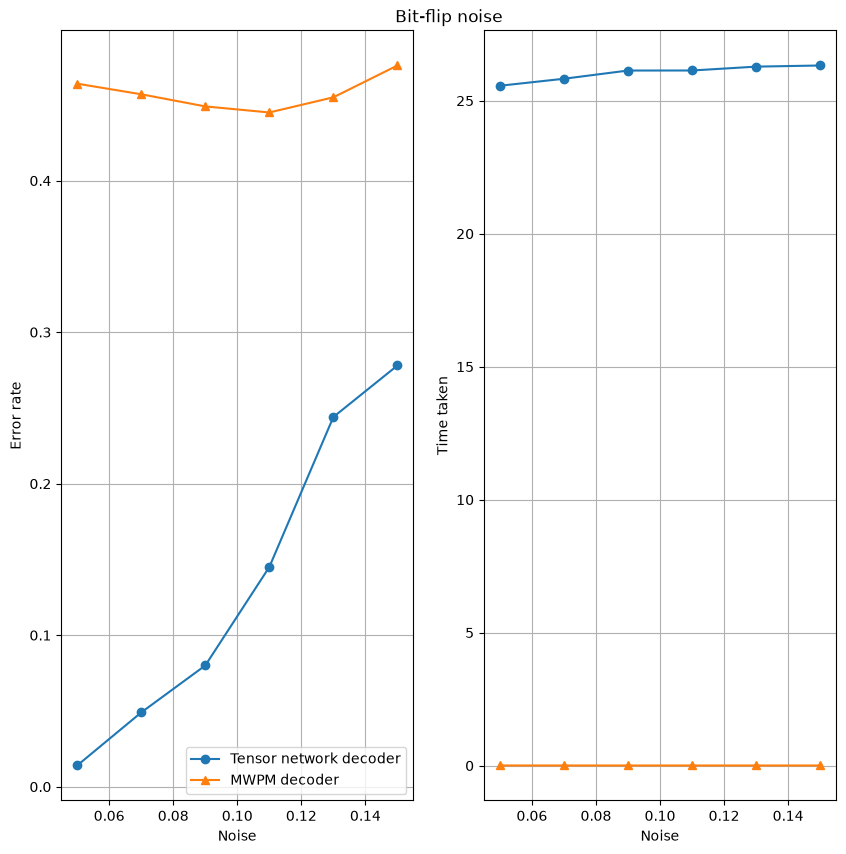

In [50]:
fig, axes = plt.subplots(1,2, figsize = (10,10))

axes[0].plot(noises,TN_rates, marker = 'o', label = 'Tensor network decoder')
axes[0].plot(noises,MWPM_rates, marker = '^', label = 'MWPM decoder')

axes[1].plot(noises, TN_times, marker= 'o')
axes[1].plot(noises, MWPM_times, marker = '^')

axes[0].set_xlabel('Noise')
axes[1].set_xlabel('Noise')
axes[0].set_ylabel('Error rate')
axes[1].set_ylabel('Time taken')

axes[0].legend()

axes[0].grid(True)
axes[1].grid(True)

plt.title("Bit-flip noise", x=-.1,y=1)

### We observe that TN beats MWPM in accuracy (likely up to some crossover noise-value). Meanwhile, MWPM beats out TN significantly in speed, as expected